## Phần 1: Khởi tạo và đọc dữ liệu

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
pd.set_option('display.max_columns', None)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob, json
from datetime import datetime
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f'Kích thước dữ liệu Train ban đầu: {train.shape}')
print(f'Kích thước dữ liệu Test ban đầu:  {test.shape}')

train.head()

Kích thước dữ liệu Train ban đầu: (1460, 81)
Kích thước dữ liệu Test ban đầu:  (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Tính tỷ lệ thiếu (%) của từng cột
missing_percent = (train.isnull().sum() / len(train)) * 100

# Lọc ra các cột có tỷ lệ thiếu > 70%
high_missing_cols = missing_percent[missing_percent > 70]
print("Các cột bị thiếu trên 70% dữ liệu:")
print(high_missing_cols)

Các cột bị thiếu trên 70% dữ liệu:
Alley          93.767123
PoolQC         99.520548
Fence          80.753425
MiscFeature    96.301370
dtype: float64


In [5]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

train_step1 = train.drop(columns=to_drop)
test_step1 = test.drop(columns=to_drop)

print(f'Kích thước Train sau khi làm sạch: {train_step1.shape}')
print(f'Kích thước Test sau khi làm sạch:  {test_step1.shape}')

print(
    'Các cột còn lại trong Train:',
    [c for c in to_drop if c in train_step1.columns],
)

Kích thước Train sau khi làm sạch: (1460, 76)
Kích thước Test sau khi làm sạch:  (1459, 75)
Các cột còn lại trong Train: []


In [6]:
def export_submission(
    test_ids, predictions_log, output_filename='submission.csv'
):

  # Biến đổi ngược từ log(1 + p) về giá tiền thực tế (USD)
  final_prices = np.expm1(predictions_log)
  sub_df = pd.DataFrame({'Id': test_ids, 'SalePrice': final_prices.flatten()})
  sub_df.to_csv(output_filename, index=False)
  print(f'Đã xuất thành công file submission tại: {output_filename}')
  print(f'Số lượng bản ghi: {len(sub_df)}')
  return sub_df

test_ids = test['Id'].values
print('Đã lưu lại chuỗi ID tập Test để nộp bài')

Đã lưu lại chuỗi ID tập Test để nộp bài


## Phần 2: Khai phá dữ liệu (EDA)

### Xem cấu trúc dữ liệu

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


### Thống kê mô tả

In [10]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [11]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Phân tích biến mục tiêu SalePrice

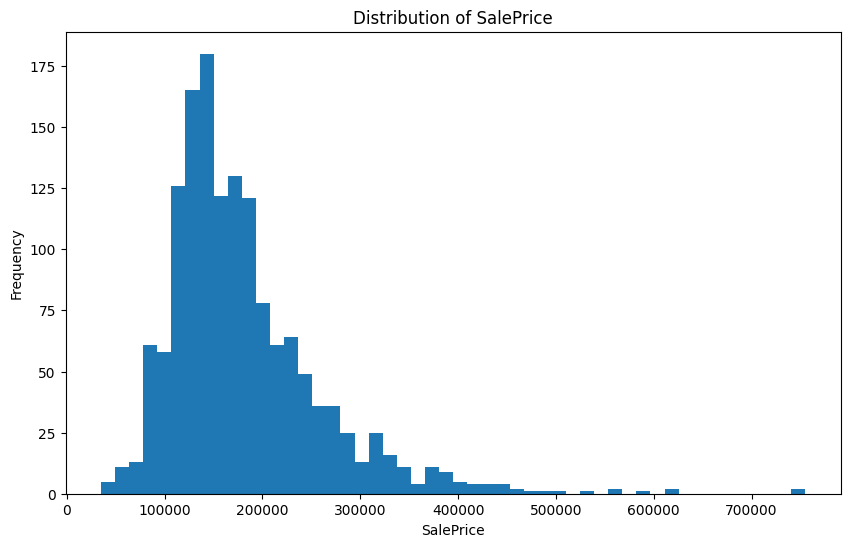

In [12]:
plt.figure(figsize=(10, 6))

plt.hist(train["SalePrice"], bins=50)

plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("Distribution of SalePrice")

plt.show()

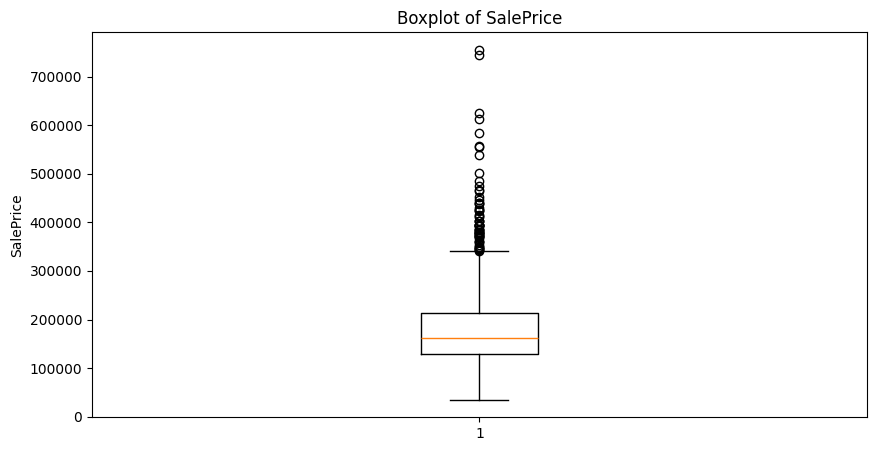

In [13]:
plt.figure(figsize=(10, 5))

plt.boxplot(train["SalePrice"])

plt.ylabel("SalePrice")
plt.title("Boxplot of SalePrice")

plt.show()

## Kiểm tra phân phối log(SalePrice)

In [14]:
log_saleprice = np.log1p(train["SalePrice"])

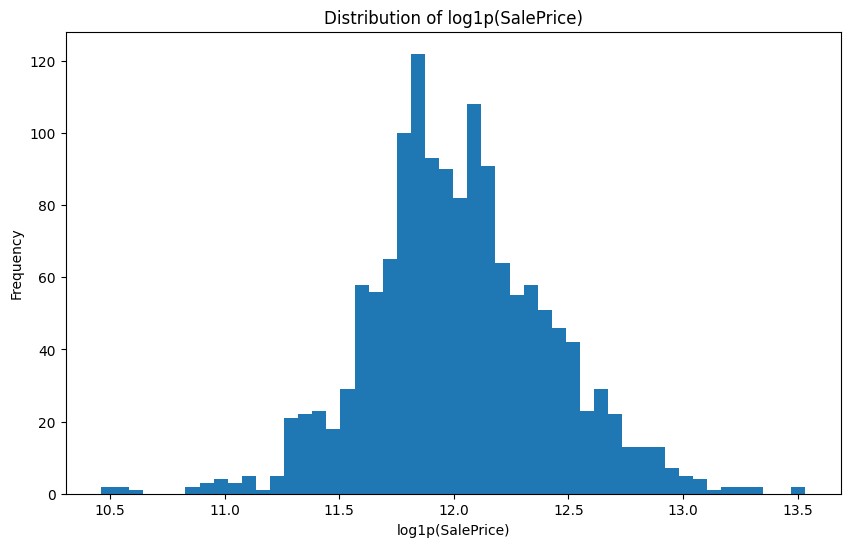

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(log_saleprice, bins=50)

plt.xlabel("log1p(SalePrice)")
plt.ylabel("Frequency")
plt.title("Distribution of log1p(SalePrice)")

plt.show()

In [16]:
print("Skewness trước log:", train["SalePrice"].skew())
print("Skewness sau log  :", log_saleprice.skew())

Skewness trước log: 1.8828757597682129
Skewness sau log  : 0.12134661989685333


## Phân tích missing values

In [17]:
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [18]:
missing_percent = (
    train.isnull().mean() * 100
).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Count": train.isnull().sum(),
    "Missing %": train.isnull().mean() * 100
})

missing_table = missing_table[
    missing_table["Missing Count"] > 0
].sort_values(
    "Missing %",
    ascending=False
)

missing_table

,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


## Trực quan hóa missing values

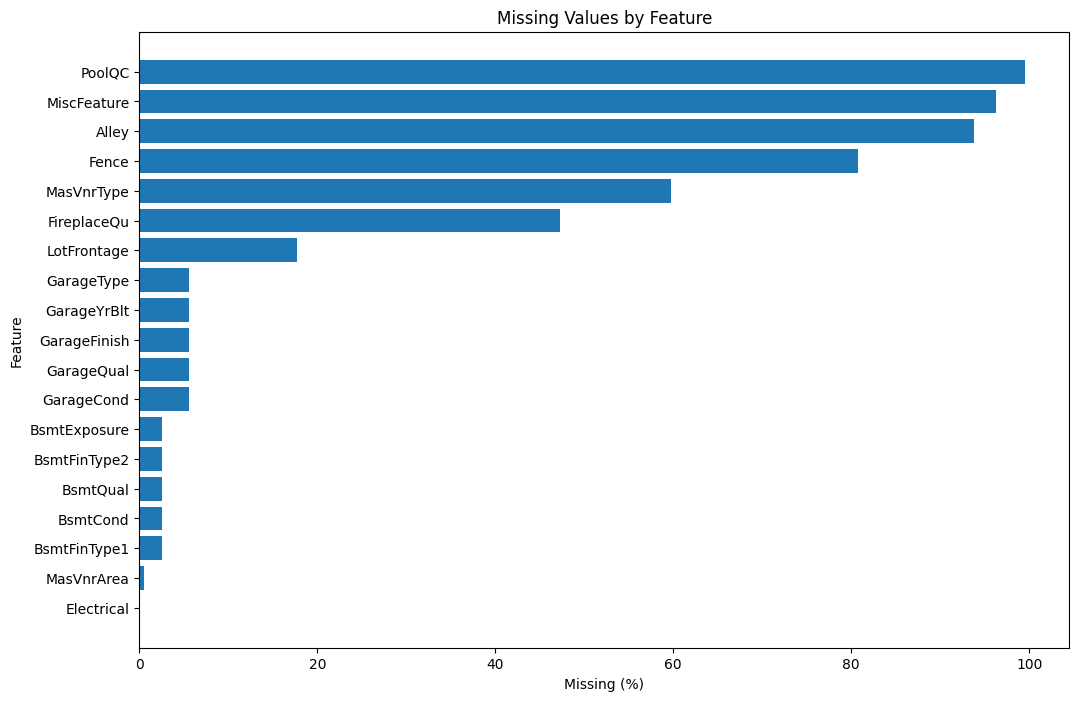

In [19]:
plt.figure(figsize=(12, 8))

plt.barh(
    missing_table.index,
    missing_table["Missing %"]
)

plt.xlabel("Missing (%)")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")

plt.gca().invert_yaxis()

plt.show()

## Kiểm tra & Xử lí dữ liệu bị thiếu

In [20]:
df = train.copy()

print(type(df))
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
(1460, 81)


In [21]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtExposure",
    "BsmtFinType2",
    "BsmtQual",
    "BsmtCond",
    "BsmtFinType1"
]

for col in none_cols:
    df[col] = df[col].fillna("None")

In [22]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [23]:
df["LotFrontage"] = (
    df.groupby("Neighborhood")["LotFrontage"]
    .transform(
        lambda x: x.fillna(x.median())
    )
)

In [24]:
df["Electrical"] = df["Electrical"].fillna(
    df["Electrical"].mode()[0]
)

In [25]:
missing_after = df.isnull().sum()

missing_after = missing_after[
    missing_after > 0
].sort_values(ascending=False)

print(missing_after)

Series([], dtype: int64)


In [26]:
# Xuất dữ liệu đã làm sạch ra file CSV
df.to_csv('train_cleaned.csv', index=False)

print('Đã lưu dữ liệu sạch thành công vào file: train_cleaned.csv')

Đã lưu dữ liệu sạch thành công vào file: train_cleaned.csv


In [27]:
# Kiểm tra tổng số ô bị NaN trong toàn bộ DataFrame
total_missing = df.isnull().sum().sum()
print(f'Tổng số giá trị NaN còn lại: {total_missing}')

Tổng số giá trị NaN còn lại: 0


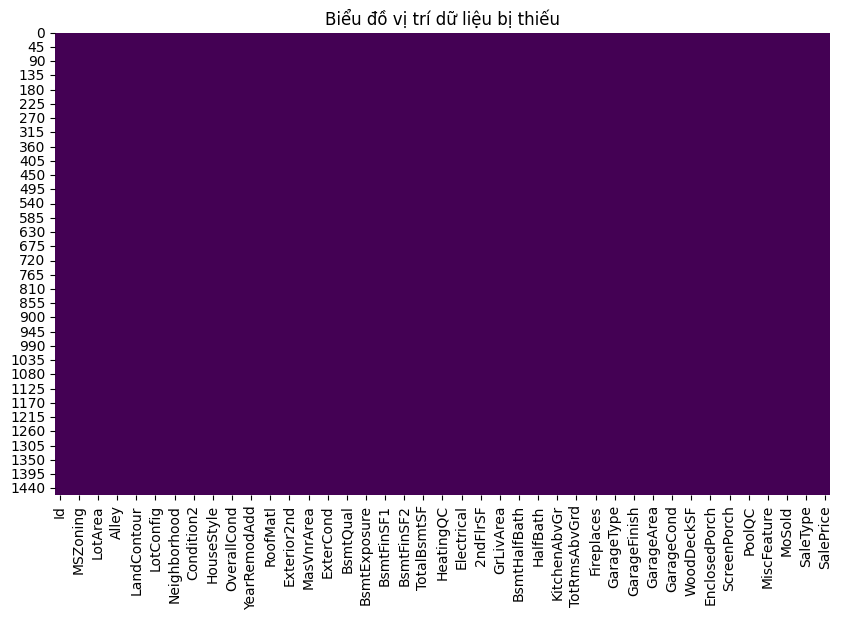

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Biểu đồ vị trí dữ liệu bị thiếu')
plt.show()

In [29]:
duplicate_rows = train.drop(columns=["Id"]).duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn (bỏ qua cột Id): {duplicate_rows}")

duplicate_ids = train["Id"].duplicated().sum()
print(f"Số lượng Id trùng lặp: {duplicate_ids}")

Số dòng trùng lặp hoàn toàn (bỏ qua cột Id): 0
Số lượng Id trùng lặp: 0


## Phân loại biến Numerical và Categorical

In [30]:
# 1. Tạo bản sao tập dữ liệu
X = train.copy()

# 2. Chuyển MSSubClass về kiểu chuỗi (Categorical) đúng bản chất
X['MSSubClass'] = X['MSSubClass'].astype(str)

# 3. Loại boỏ Id và SalePrice khỏi tâp đặc trưng X
X = X.drop(columns=['Id', 'SalePrice'], errors='ignore')

# 4. Phân loại lại Numerical và Categorical
numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print('Numerical count:', len(numerical_cols))  # Sẽ còn 36 cột
print('Categorical count:', len(categorical_cols))  # Sẽ tăng lên 44 cột

Numerical count: 35
Categorical count: 44


In [31]:
print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical columns:
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',

## Phân tích biến numerical

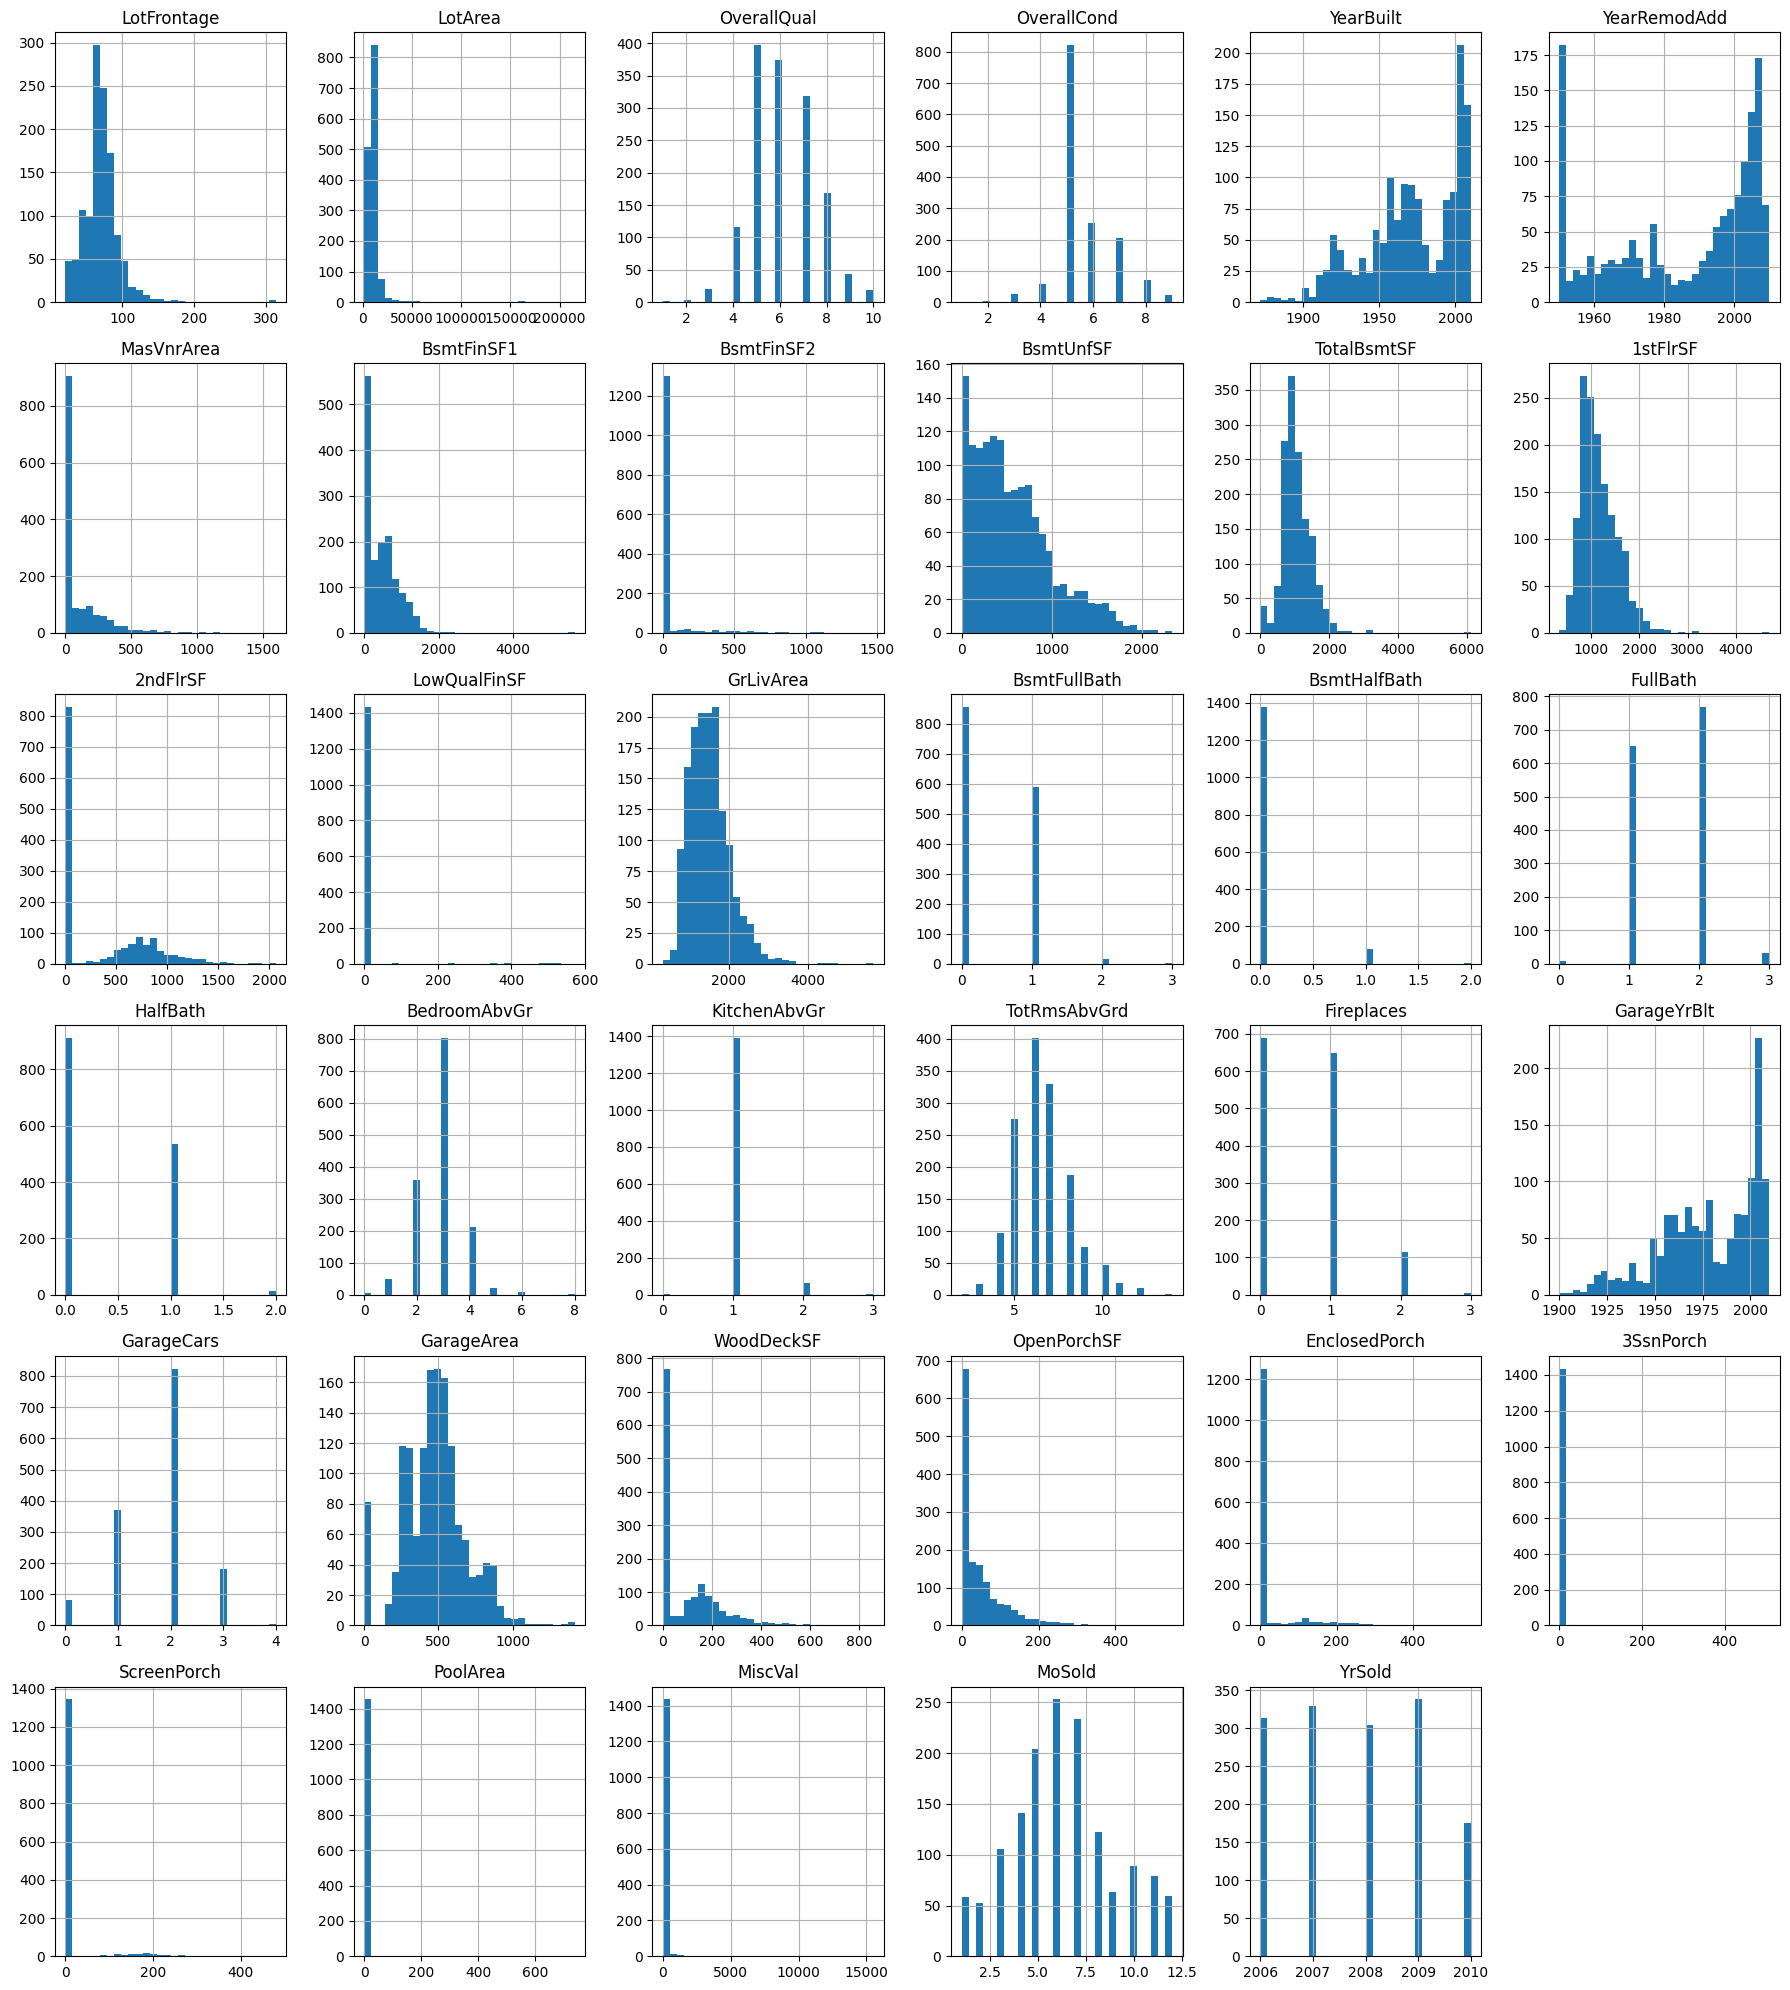

In [32]:
train[numerical_cols].hist(
    figsize=(18, 20),
    bins=30
)

plt.tight_layout()
plt.show()

## Phân tích tương quan với SalePrice

In [33]:
# Cách 1: Thêm 'SalePrice' vào danh sách biến số để tính tương quan
cols_to_corr = numerical_cols + ['SalePrice']
corr = train[cols_to_corr].corr()

# Lấy độ tương quan riêng với SalePrice và sắp xếp giảm dần
saleprice_corr = corr['SalePrice'].sort_values(ascending=False)

print(saleprice_corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


In [34]:
top_corr = (
    saleprice_corr
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

print(top_corr)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


## Vẽ heatmap tương quan

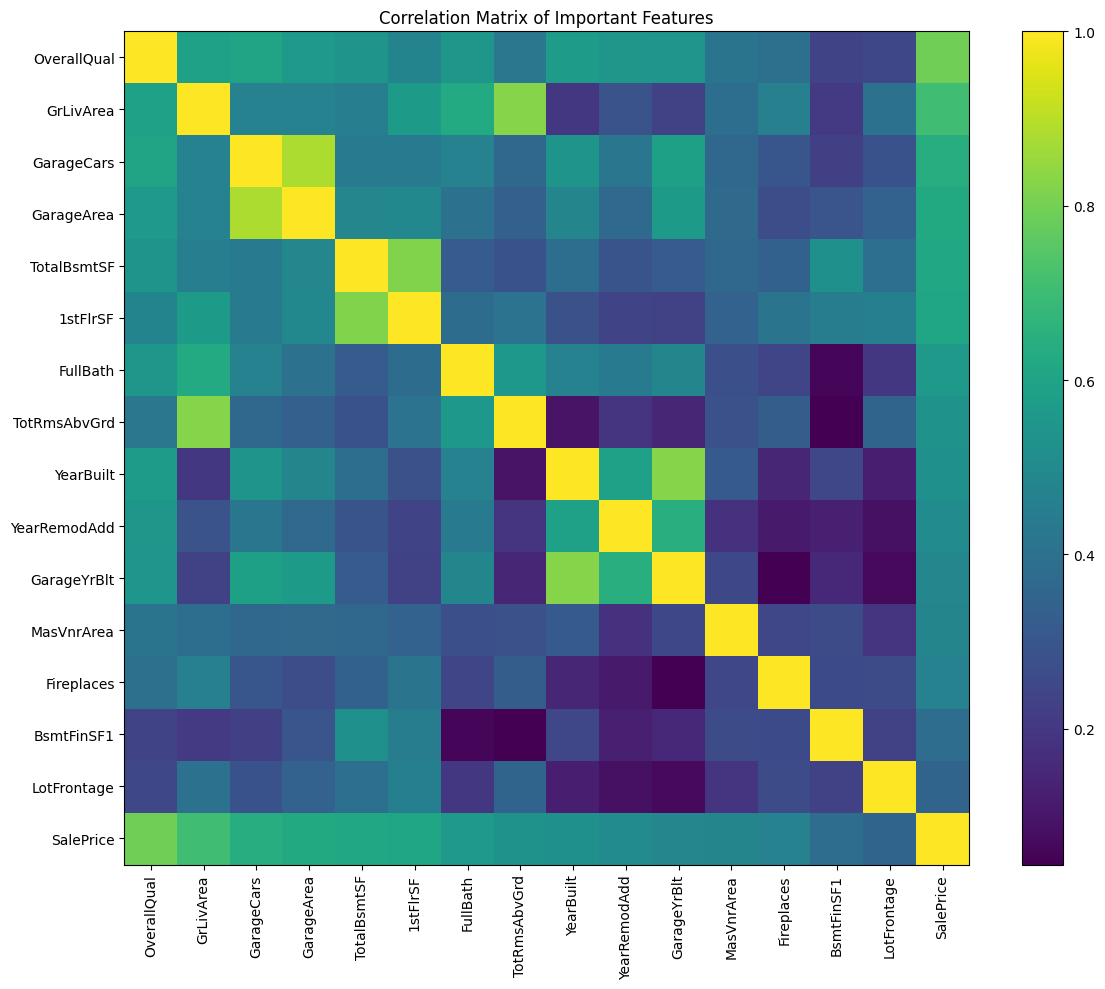

In [35]:
top_features = top_corr.index.tolist() + ["SalePrice"]

corr_matrix = train[top_features].corr()

plt.figure(figsize=(12, 10))

plt.imshow(
    corr_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(top_features)),
    top_features,
    rotation=90
)

plt.yticks(
    range(len(top_features)),
    top_features
)

plt.title("Correlation Matrix of Important Features")

plt.tight_layout()
plt.show()

## Quan hệ giữa OverallQual và SalePrice

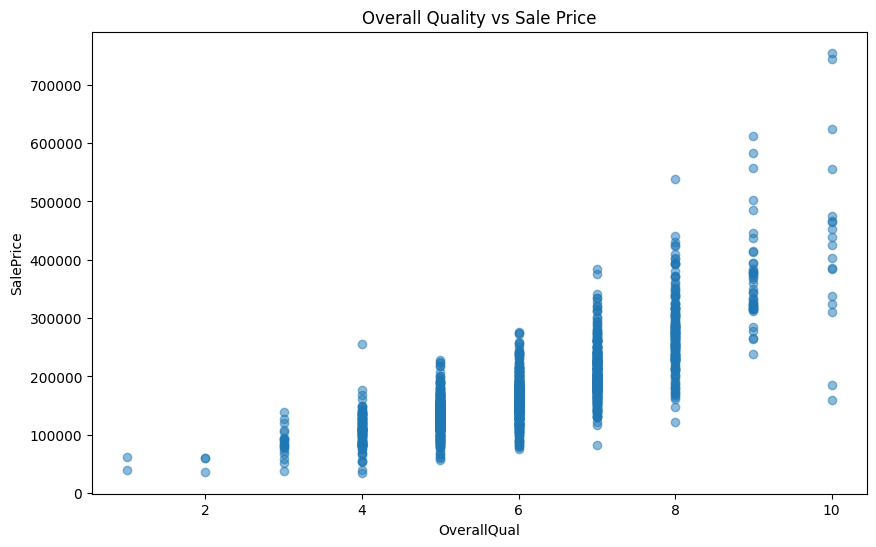

In [36]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train["OverallQual"],
    train["SalePrice"],
    alpha=0.5
)

plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Overall Quality vs Sale Price")

plt.show()

## Quan hệ GrLivArea và SalePrice

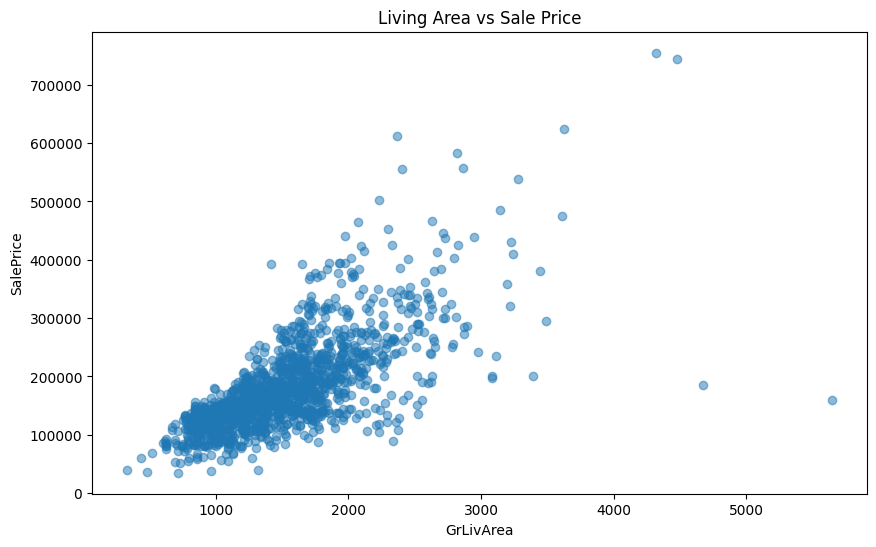

In [37]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train["GrLivArea"],
    train["SalePrice"],
    alpha=0.5
)

plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Living Area vs Sale Price")

plt.show()

## Quan hệ YearBuilt và SalePrice

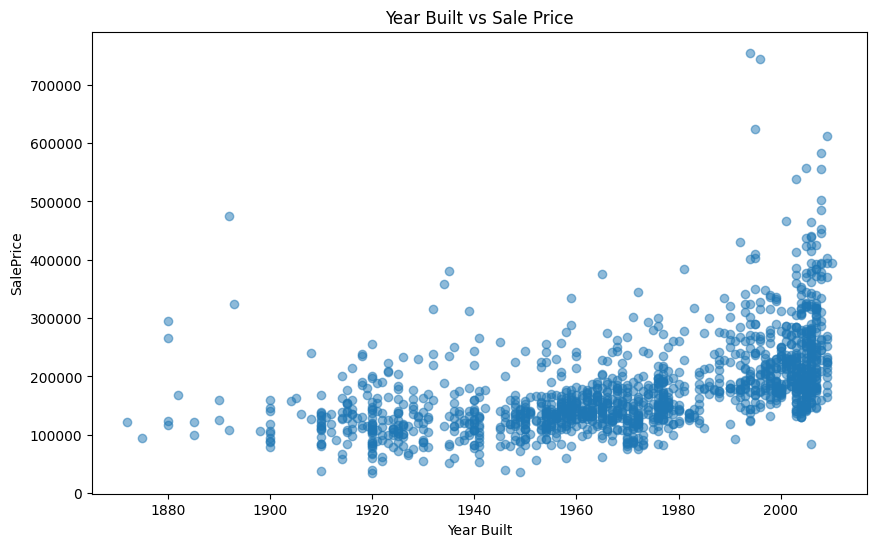

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train["YearBuilt"],
    train["SalePrice"],
    alpha=0.5
)

plt.xlabel("Year Built")
plt.ylabel("SalePrice")
plt.title("Year Built vs Sale Price")

plt.show()

## EDA cho biến categorical

In [39]:
neighborhood_count = (
    train["Neighborhood"]
    .value_counts()
)

print(neighborhood_count)

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64


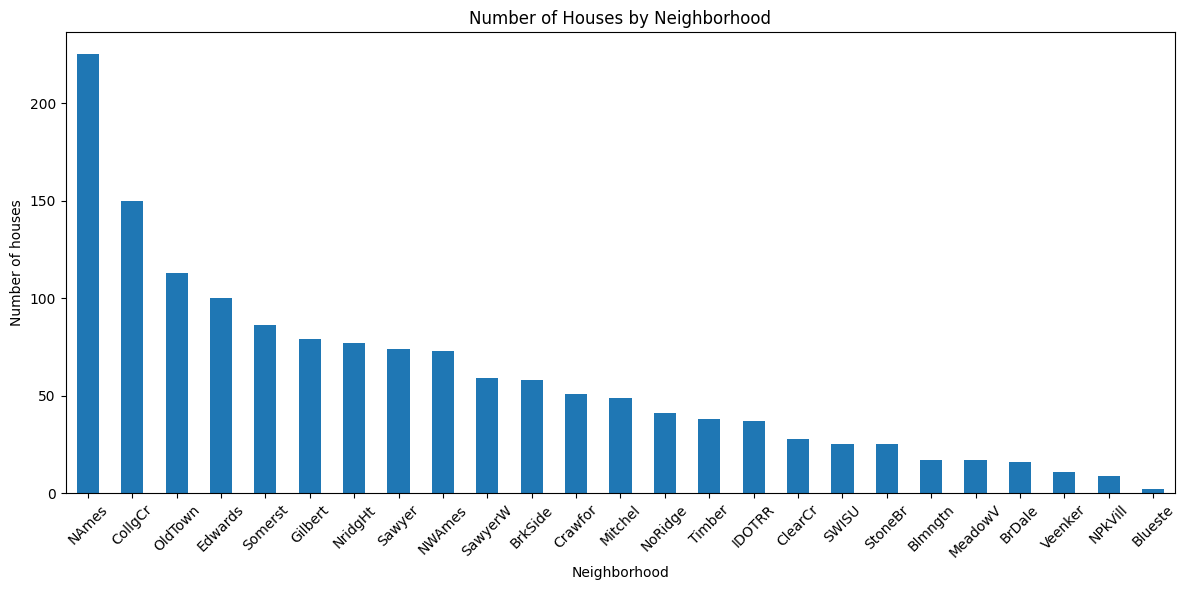

In [40]:
plt.figure(figsize=(12, 6))

neighborhood_count.plot(
    kind="bar"
)

plt.xlabel("Neighborhood")
plt.ylabel("Number of houses")
plt.title("Number of Houses by Neighborhood")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
neighborhood_price = (
    train.groupby("Neighborhood")["SalePrice"]
    .median()
    .sort_values(ascending=False)
)

print(neighborhood_price)

Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Veenker    218000.0
Crawfor    200624.0
ClearCr    200250.0
CollgCr    197200.0
Blmngtn    191000.0
NWAmes     182900.0
Gilbert    181000.0
SawyerW    179900.0
Mitchel    153500.0
NPkVill    146000.0
NAmes      140000.0
SWISU      139500.0
Blueste    137500.0
Sawyer     135000.0
BrkSide    124300.0
Edwards    121750.0
OldTown    119000.0
BrDale     106000.0
IDOTRR     103000.0
MeadowV     88000.0
Name: SalePrice, dtype: float64


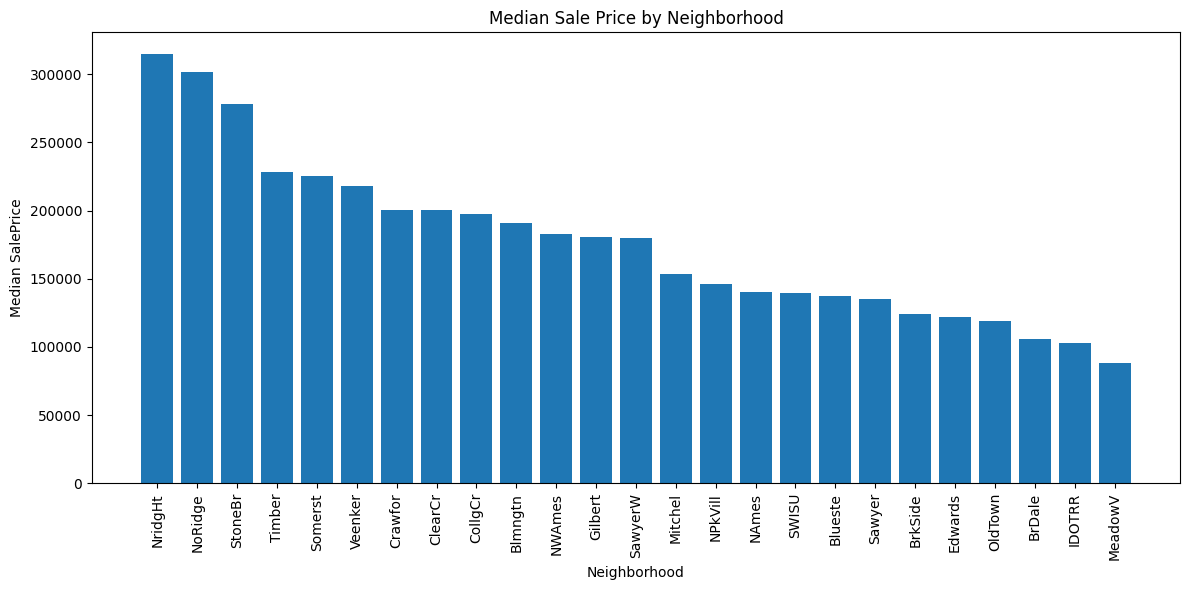

In [42]:
plt.figure(figsize=(12, 6))

plt.bar(
    neighborhood_price.index,
    neighborhood_price.values
)

plt.xlabel("Neighborhood")
plt.ylabel("Median SalePrice")
plt.title("Median Sale Price by Neighborhood")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Kiểm tra outlier

In [43]:
outlier_cols = [
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
    "SalePrice"
]

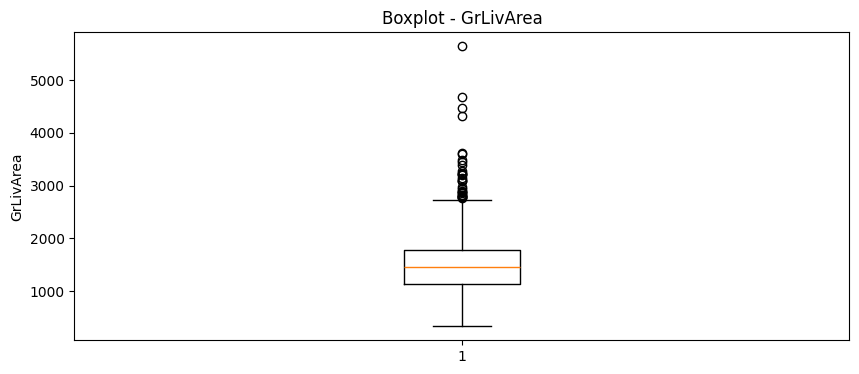

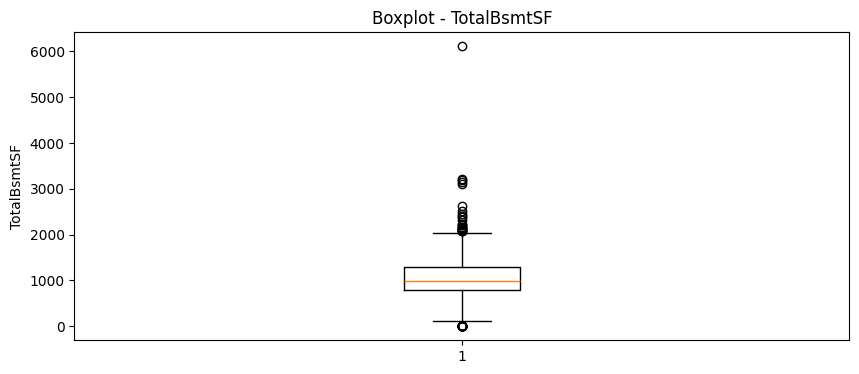

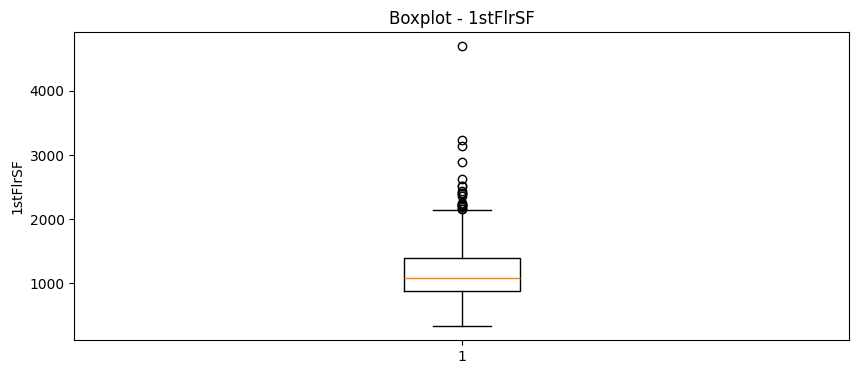

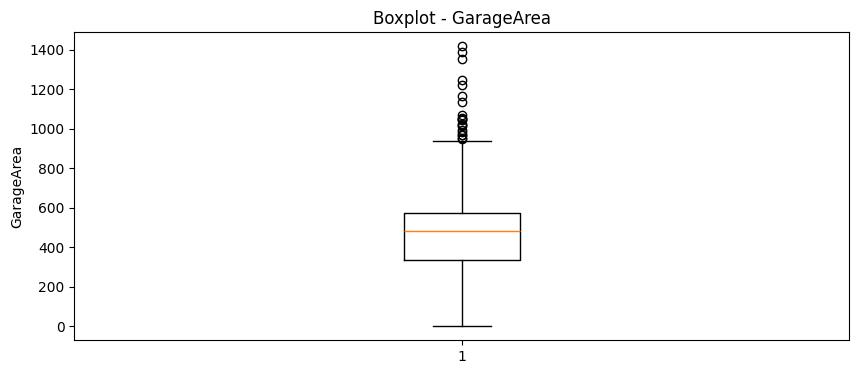

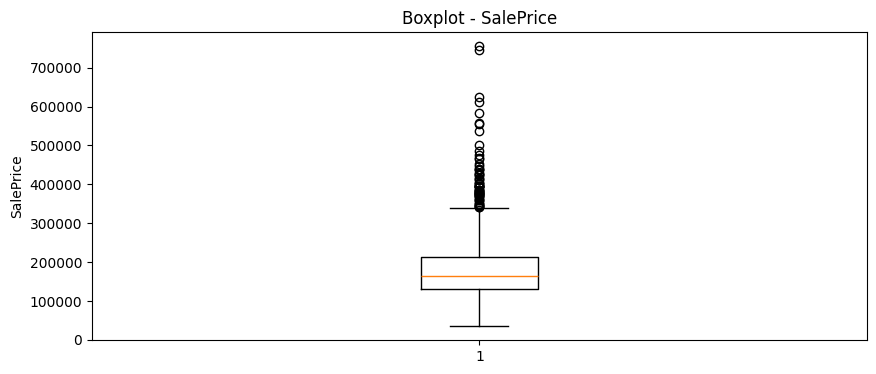

In [44]:
for col in outlier_cols:

    plt.figure(figsize=(10, 4))

    plt.boxplot(train[col].dropna())

    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)

    plt.show()

## Xử lí outiler

In [45]:
# Xóa 2 điểm outlier cực đoan làm méo lệch mô hình
train = train[
    ~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))
]
# 2. Kiểm tra lại số dòng
print("Số dòng sau khi loại bỏ outlier:", len(train))

Số dòng sau khi loại bỏ outlier: 1458


In [85]:
import os

# Đặt API Key vào biến môi trường
os.environ["WANDB_API_KEY"] = "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"

import wandb

# W&B sẽ tự đọc API Key từ os.environ mà không hỏi gì thêm
wandb.login()

True

## Kiểm tra dữ liệu sau preprocessing

In [91]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nData types:")
print(df.dtypes.value_counts())

Shape: (1460, 81)

Missing values:
0

Data types:
object     43
int64      35
float64     3
Name: count, dtype: int64


## Tách target

In [92]:
y = np.log1p(df["SalePrice"])

X = df.drop(columns=["SalePrice", "Id"])

In [93]:
print("X:", X.shape)
print("y:", y.shape)

X: (1460, 79)
y: (1460,)


## Chia Train / Validation

In [94]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)

X_train: (1168, 79)
X_val  : (292, 79)
y_train: (1168,)
y_val  : (292,)


In [95]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns

print("Số categorical columns:", len(categorical_cols))
print(categorical_cols.tolist())

Số categorical columns: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [96]:
X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=False
)

X_val = pd.get_dummies(
    X_val,
    columns=categorical_cols,
    drop_first=False
)

In [97]:
X_train, X_val = X_train.align(
    X_val,
    join="outer",
    axis=1,
    fill_value=0
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (1168, 302)
X_val: (292, 302)


In [98]:
print("Còn object trong X_train:",
      X_train.select_dtypes(include=["object"]).shape[1])

print("Còn object trong X_val:",
      X_val.select_dtypes(include=["object"]).shape[1])

print("Missing X_train:", X_train.isnull().sum().sum())
print("Missing X_val:", X_val.isnull().sum().sum())

Còn object trong X_train: 0
Còn object trong X_val: 0
Missing X_train: 0
Missing X_val: 0


In [99]:
import numpy as np

# Kiểm tra độ lệch chuẩn trực tiếp trên X_train
zero_std_cols = X_train.columns[
    np.isclose(X_train.std(numeric_only=True), 0)
]

print("Số feature có std ≈ 0:", len(zero_std_cols))
print(zero_std_cols.tolist())

Số feature có std ≈ 0: 2
['Electrical_Mix', 'RoofMatl_Membran']


In [100]:
X_train = X_train.drop(columns=zero_std_cols)
X_val = X_val.drop(columns=zero_std_cols)

In [135]:
# ==========================================
# PREPROCESSING X_TEST
# ==========================================

X_test = test.drop(columns=["Id"]).copy()

# One-hot encoding
X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False
)

# Đảm bảo X_test có đúng các feature như X_train
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Kiểm tra
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("Object X_test:",
      X_test.select_dtypes(include=["object"]).shape[1])

print("Missing X_test:",
      X_test.isnull().sum().sum())

X_train: (1168, 300)
X_val  : (292, 300)
X_test : (1459, 300)
Object X_test: 0
Missing X_test: 330


In [139]:
# ==========================================
# XỬ LÝ MISSING CHO X_TEST
# ==========================================

# 1. LotFrontage:
# điền median theo Neighborhood
X_test["LotFrontage"] = (
    X_test.groupby("Neighborhood")["LotFrontage"]
    .transform(lambda x: x.fillna(x.median()))
)

# Nếu vẫn còn NaN thì dùng median toàn bộ train
X_test["LotFrontage"] = X_test["LotFrontage"].fillna(
    X["LotFrontage"].median()
)

# 2. Các cột mà NaN có ý nghĩa "không có"
X_test["GarageYrBlt"] = X_test["GarageYrBlt"].fillna(0)
X_test["MasVnrArea"] = X_test["MasVnrArea"].fillna(0)

# 3. Các biến số còn lại: dùng median
median_cols = [
    "BsmtFullBath",
    "BsmtHalfBath",
    "GarageArea",
    "GarageCars",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFinSF1",
    "BsmtFinSF2"
]

for col in median_cols:
    X_test[col] = X_test[col].fillna(
        X[col].median()
    )

In [140]:
X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False
)

In [141]:
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [142]:
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("Object X_test:",
      X_test.select_dtypes(include=["object"]).shape[1])

print("Missing X_test:",
      X_test.isna().sum().sum())

X_train: (1168, 300)
X_val  : (292, 300)
X_test : (1459, 300)
Object X_test: 0
Missing X_test: 0


## StandardScaler

In [143]:
from sklearn.preprocessing import StandardScaler

# Khởi tạo scaler
scaler = StandardScaler()

# Transform dữ liệu
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Đừng quên scale cả tập X_test nếu bạn chuẩn bị dự đoán bài nộp
# X_test_scaled = scaler.transform(X_test)

In [179]:
X_test_scaled = scaler.transform(X_test)

print("X_test_scaled:", X_test_scaled.shape)
print("NaN:", np.isnan(X_test_scaled).sum())
print("Inf:", np.isinf(X_test_scaled).sum())

X_test_scaled: (1459, 300)
NaN: 0
Inf: 0


In [144]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print(
    "Std nhỏ nhất:",
    X_train_scaled.std(axis=0).min()
)

X_train: (1168, 300)
X_val: (292, 300)
Std nhỏ nhất: 0.9999999999999997


In [145]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)

X_train_scaled: (1168, 300)
X_val_scaled: (292, 300)


In [146]:
print("Mean lớn nhất:",
      abs(X_train_scaled.mean(axis=0)).max())

print("Std nhỏ nhất:",
      X_train_scaled.std(axis=0).min())

print("Std lớn nhất:",
      X_train_scaled.std(axis=0).max())

Mean lớn nhất: 6.596853961115177e-14
Std nhỏ nhất: 0.9999999999999997
Std lớn nhất: 1.0000000000000002


In [180]:
X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

model.load_state_dict(
    torch.load("best_mlp.pth", weights_only=True)
)

model.eval()

with torch.no_grad():
    test_pred_log = model(X_test_tensor).numpy().flatten()

test_pred = np.expm1(test_pred_log)

print("Số prediction:", len(test_pred))
print("Số NaN:", np.isnan(test_pred).sum())
print("Số Inf:", np.isinf(test_pred).sum())
print("Min:", np.min(test_pred))
print("Max:", np.max(test_pred))

Số prediction: 1459
Số NaN: 0
Số Inf: 0
Min: 64244.133
Max: 853276.7


## Chuyển sang Tensor

In [181]:
import torch

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values.reshape(-1, 1),
    dtype=torch.float32
)

In [182]:
print("X_train:", X_train_tensor.shape)
print("X_val:", X_val_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("y_val:", y_val_tensor.shape)

X_train: torch.Size([1168, 300])
X_val: torch.Size([292, 300])
y_train: torch.Size([1168, 1])
y_val: torch.Size([292, 1])


## Tạo Dataset

In [183]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

In [184]:
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 1168
Validation samples: 292


## Tạo DataLoader

In [185]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [152]:
for X_batch, y_batch in train_loader:
    print("X batch:", X_batch.shape)
    print("y batch:", y_batch.shape)
    break

X batch: torch.Size([32, 300])
y batch: torch.Size([32, 1])


In [186]:
import os
import wandb

# Đặt tên notebook trực tiếp để tránh bị cảnh báo lỗi
os.environ["WANDB_NOTEBOOK_NAME"] = "house_prices.ipynb"

wandb.login()

# Khởi tạo W&B với đúng các thông tin config trong ảnh
run = wandb.init(
    project="house-prices-mlp",
    name="baseline1",
    config={
        "dataset": "House Prices",
        "train_samples": len(X_train_tensor),
        "val_samples": len(X_val_tensor),
        "num_features": X_train_tensor.shape[1],
        "batch_size": 32,
    },
)

--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\PHUONG UYEN\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 1153, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PHUONG UYEN\AppData\Local\Programs\Python\Python313\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u1ea7' in position 138: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\PHUONG UYEN\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\PHUONG UYEN\AppData\Local\Programs\Python\Python313\Lib\site-packages\traitlets\config\

# Phần 3: Xây dựng MLP

In [187]:
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

In [188]:
num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

wandb.config.update({
    "model": "MLP",
    "input_dim": input_dim,
    "hidden_layers": [256, 128, 64],
    "dropout": 0.2,
    "activation": "ReLU",
    "trainable_parameters": num_params
})

In [189]:
print(model)
print("Trainable parameters:", num_params)

MLP(
  (network): Sequential(
    (0): Linear(in_features=300, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Trainable parameters: 118273


## Loss function

In [190]:
criterion = nn.MSELoss()

## Optimizer

In [191]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [192]:
wandb.init(
    project="house-prices-mlp",
    name="mlp-baseline"
)
wandb.config.update({
    "loss_function": "MSELoss",
    "optimizer": "Adam",
    "learning_rate": 0.001
})

--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\PHUONG UYEN\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 1153, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PHUONG UYEN\AppData\Local\Programs\Python\Python313\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u1ea7' in position 138: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\PHUONG UYEN\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\PHUONG UYEN\AppData\Local\Programs\Python\Python313\Lib\site-packages\traitlets\config\

In [193]:
wandb.watch(model, log="all", log_freq=100)

## Training

In [194]:
num_epochs = 500

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0

patience = 30
counter = 0


# =========================
# W&B: theo dõi model
# =========================
wandb.watch(
    model,
    log="all",
    log_freq=100
)


for epoch in range(num_epochs):

    # =====================
    # TRAIN
    # =====================
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Xóa gradient cũ
        optimizer.zero_grad()

        # Forward
        predictions = model(X_batch)

        # Tính loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Cập nhật trọng số
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = (
        running_train_loss / len(train_loader)
    )


    # =====================
    # VALIDATION
    # =====================
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            running_val_loss += loss.item()

    avg_val_loss = (
        running_val_loss / len(val_loader)
    )


    # =====================
    # LƯU HISTORY
    # =====================
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)


    # =====================
    # W&B: LƯU KẾT QUẢ
    # =====================
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss
    })


    # =====================
    # EARLY STOPPING
    # =====================
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        counter = 0

        torch.save(
            model.state_dict(),
            "best_mlp.pth"
        )

        # W&B: lưu kết quả tốt nhất
        wandb.summary["best_val_loss"] = best_val_loss
        wandb.summary["best_epoch"] = best_epoch

    else:

        counter += 1

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch + 1}"
            )

            break


    # =====================
    # IN KẾT QUẢ
    # =====================
    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Val Loss: {avg_val_loss:.4f}"
        )

Epoch [50/500] Train Loss: 0.0094 Val Loss: 0.0276
Early stopping at epoch 78


## Load model tốt nhất

In [195]:
model.load_state_dict(
    torch.load(
        "best_mlp.pth",
        weights_only=True
    )
)

model.eval()

MLP(
  (network): Sequential(
    (0): Linear(in_features=300, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [196]:
with torch.no_grad():
    y_pred = model(X_val_tensor).numpy().flatten()

y_true = y_val_tensor.numpy().flatten()

In [197]:
final_rmsle = np.sqrt(
    np.mean(
        (y_true - y_pred) ** 2
    )
)

print(f"Final Validation RMSLE: {final_rmsle:.4f}")

Final Validation RMSLE: 0.1543


In [198]:
wandb.summary["final_rmsle"] = final_rmsle
wandb.summary["best_val_loss"] = best_val_loss
wandb.summary["best_epoch"] = best_epoch

In [199]:
wandb.finish()

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train_loss,▇▄█▇▆▆▅▄▇▇▄▆▅▅▃▆▅▃▃▄▂▃▃▂▂▃▃▅▃▂▃▇▂▃▃▁▂▂▂▂
val_loss,▄▂▇▄▃▄▃▃▂▄▄▄▆▇▃▅▄▁▂▃▄▃▃▅▅▂▃██▄▅▃▄▄▅▄▅▄▃▅
best_epoch,48
best_val_loss,0.02197
epoch,78
final_rmsle,0.15428
train_loss,0.00632
val_loss,0.02634


## Đánh giá RMSLE

In [200]:
import numpy as np

model.eval()

with torch.no_grad():

    y_pred = model(X_val_tensor)

y_pred = y_pred.numpy().flatten()
y_true = y_val_tensor.numpy().flatten()

In [201]:
rmsle = np.sqrt(
    np.mean(
        (y_true - y_pred) ** 2
    )
)

print("Validation RMSLE:", rmsle)

Validation RMSLE: 0.1542833


In [202]:
pred_price = np.expm1(y_pred)
true_price = np.expm1(y_true)

In [203]:
for i in range(10):

    print(
        f"Thực tế: {true_price[i]:,.0f} | "
        f"Dự đoán: {pred_price[i]:,.0f}"
    )

Thực tế: 154,500 | Dự đoán: 143,030
Thực tế: 325,000 | Dự đoán: 386,096
Thực tế: 115,000 | Dự đoán: 108,571
Thực tế: 159,000 | Dự đoán: 143,718
Thực tế: 315,500 | Dự đoán: 384,151
Thực tế: 75,500 | Dự đoán: 81,141
Thực tế: 311,500 | Dự đoán: 224,710
Thực tế: 146,000 | Dự đoán: 159,214
Thực tế: 84,500 | Dự đoán: 81,963
Thực tế: 135,500 | Dự đoán: 143,017


In [204]:
X_test_scaled = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("NaN trong X_test:", X_test.isna().sum().sum())
print("NaN trong X_test_scaled:", np.isnan(X_test_scaled).sum())

X_test shape: (1459, 300)
X_test_scaled shape: (1459, 300)
NaN trong X_test: 0
NaN trong X_test_scaled: 0


In [205]:
# Align đúng 300 features
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Scale bằng scaler ĐÃ FIT trên train
X_test_scaled = scaler.transform(X_test)

# Kiểm tra
print("NaN:", np.isnan(X_test_scaled).sum())
print("Inf:", np.isinf(X_test_scaled).sum())

# Tensor
X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

# Load best model
model.load_state_dict(
    torch.load(
        "best_mlp.pth",
        weights_only=True
    )
)

model.eval()

# Prediction
with torch.no_grad():
    test_pred_log = model(
        X_test_tensor
    ).numpy().flatten()

# Đưa từ log1p về SalePrice
test_pred = np.expm1(test_pred_log)

# Kiểm tra prediction
print("Số prediction:", len(test_pred))
print("Số NaN:", np.isnan(test_pred).sum())
print("Số Inf:", np.isinf(test_pred).sum())
print("Min:", test_pred.min())
print("Max:", test_pred.max())

NaN: 0
Inf: 0
Số prediction: 1459
Số NaN: 0
Số Inf: 0
Min: 51046.715
Max: 1.0456481e+06


In [173]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_pred
})

print(submission.shape)
print(submission.isna().sum())
print(submission.head())

(1459, 2)
Id           0
SalePrice    0
dtype: int64
     Id      SalePrice
0  1461  131308.031250
1  1462  168309.296875
2  1463  180916.750000
3  1464  189565.718750
4  1465  201705.343750


In [206]:
submission.to_csv(
    "submission.csv",
    index=False
)